In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2

In [4]:
from collections import Counter
from pathlib import Path

# function to determine the number of instances of each class
def sort_classes(folder_path):
    counts = Counter()
    for txt_file in Path(folder_path).glob("*.txt"):
        with open(txt_file, "r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    class_id = int(line.split()[0])
                    counts[class_id] += 1
                except (ValueError, IndexError):
                    pass  # skip malformed rows

    return dict(sorted(counts.items()))

In [13]:
import pandas as pd
from pathlib import Path

train_path = Path(r'C:\Users\bdsc_\Documents\Computer-Vision-Pipeline\data\weld_data\train\images')
val_path = Path(r'C:\Users\bdsc_\Documents\Computer-Vision-Pipeline\data\weld_data\valid\images')
test_path = Path(r'C:\Users\bdsc_\Documents\Computer-Vision-Pipeline\data\weld_data\test\images')


def create_dataframe(path):
    paths = [
        p.parts[-2:]
        for p in path.rglob('*.*')
        if p.is_file()
    ]

    df = pd.DataFrame(
        paths,
        columns=['Class', 'Images']
    )

    df = df.sort_values(
        'Class',
        ascending=True
    )

    df.reset_index(
        drop=True,
        inplace=True
    )

    return df


train_df = create_dataframe(train_path)
val_df = create_dataframe(val_path)
test_df = create_dataframe(test_path)


print(train_df)
print(val_df)
print(test_df)

Empty DataFrame
Columns: [Class, Images]
Index: []
Empty DataFrame
Columns: [Class, Images]
Index: []
Empty DataFrame
Columns: [Class, Images]
Index: []


In [6]:
{
  "names": {
    "0": "Porosity",
    "1": "Inclusion",
    "2": "Undercut",
    "3": "Burn-through",
    "4": "Crack",
    "5": "Overlap",
    "6": "Reference 1",
    "7": "Reference 2",
    "8": "Reference 3",
    "9": "Hidden Porosity",
    "10": "Shrinkage",
    "11": "Lack of Fusion",
    "12": "Incomplete Root Penetration"
  }
}

{'names': {'0': 'Porosity',
  '1': 'Inclusion',
  '2': 'Undercut',
  '3': 'Burn-through',
  '4': 'Crack',
  '5': 'Overlap',
  '6': 'Reference 1',
  '7': 'Reference 2',
  '8': 'Reference 3',
  '9': 'Hidden Porosity',
  '10': 'Shrinkage',
  '11': 'Lack of Fusion',
  '12': 'Incomplete Root Penetration'}}

In [11]:
print(sort_classes(r'C:\Users\Administrator\Downloads\Computer-Vision-Pipeline\data\weld_data\train\labels'))


{0: 24426, 1: 5895, 2: 395, 3: 1, 6: 2586, 7: 2255, 8: 5, 10: 97, 11: 191, 12: 118}


In [14]:
print(sort_classes(r'C:\Users\Administrator\Downloads\Computer-Vision-Pipeline\data\weld_data\test\labels'))
print(sort_classes(r'C:\Users\Administrator\Downloads\Computer-Vision-Pipeline\data\weld_data\valid\labels'))



{0: 2890, 1: 726, 2: 44, 6: 352, 7: 280, 10: 12, 11: 11, 12: 18}
{0: 5923, 1: 1473, 2: 96, 4: 1, 6: 687, 7: 574, 10: 22, 11: 26, 12: 30}


Checking for images with missing label files

In [15]:
from pathlib import Path


def get_images_without_labels(image_folder, label_folder):
    image_folder = Path(image_folder)
    label_folder = Path(label_folder)

    images_without_labels = []

    for img_path in image_folder.glob("*.*"):
        label_path = label_folder / f"{img_path.stem}.txt"

        if not label_path.exists():
            images_without_labels.append(img_path.name)

    return images_without_labels

In [16]:
images = get_images_without_labels(
    r'C:\Users\bdsc_\Documents\Computer-Vision-Pipeline\data\weld_data\test\images',
    r'C:\Users\bdsc_\Documents\Computer-Vision-Pipeline\data\weld_data\test\labels'
)

print(len(images))
print(images[:10])

0
[]


Checking for images with no actual defects 

In [17]:
from pathlib import Path

def count_empty_labels(label_folder):
    count = 0

    for txt_file in Path(label_folder).glob("*.txt"):
        if txt_file.stat().st_size == 0:
            count += 1

    return count

In [18]:
print(count_empty_labels(r'C:\Users\bdsc_\Documents\Computer-Vision-Pipeline\data\weld_data\train\labels'))
print(count_empty_labels(r'C:\Users\bdsc_\Documents\Computer-Vision-Pipeline\data\weld_data\val\labels'))
print(count_empty_labels(r'C:\Users\bdsc_\Documents\Computer-Vision-Pipeline\data\weld_data\test\labels'))


0
0
0


In [19]:
from pathlib import Path
from collections import Counter


def count_images_per_class(folder_path):
    counts = Counter()

    for txt_file in Path(folder_path).glob("*.txt"):
        image_classes = set()

        with open(txt_file, "r") as f:
            for line in f:
                line = line.strip()

                if not line:
                    continue

                try:
                    class_id = int(line.split()[0])
                    image_classes.add(class_id)

                except (ValueError, IndexError):
                    continue

        # count the image once for every class present
        for class_id in image_classes:
            counts[class_id] += 1

    return dict(sorted(counts.items()))

In [22]:
count_images_per_class(r'C:\Users\Administrator\Downloads\Computer-Vision-Pipeline\data\weld_data\train\labels')

{0: 9776,
 1: 3146,
 2: 300,
 3: 1,
 6: 2586,
 7: 2255,
 8: 5,
 10: 89,
 11: 149,
 12: 104}

In [23]:
import json
import pandas as pd
import numpy as np
from collections import defaultdict

# Load COCO annotations
with open(r"C:\Users\Administrator\Downloads\Computer-Vision-Pipeline\data\weld_data\instances_train.json", "r") as f:
    coco = json.load(f)

# Category ID -> Category Name
cat_map = {c["id"]: c["name"] for c in coco["categories"]}

# Collect classes present in each image
image_classes = defaultdict(set)

for ann in coco["annotations"]:
    image_id = ann["image_id"]
    class_name = cat_map[ann["category_id"]]
    image_classes[image_id].add(class_name)

# Create binary image-class matrix
all_classes = sorted(cat_map.values())

rows = []
for image_id, classes in image_classes.items():
    row = {cls: int(cls in classes) for cls in all_classes}
    row["image_id"] = image_id
    rows.append(row)

df = pd.DataFrame(rows).set_index("image_id")

print(df.head())

          class_0  class_1  class_10  class_11  class_12  class_2  class_3  \
image_id                                                                     
1               1        0         0         0         0        0        0   
2               1        0         0         0         0        0        0   
4               1        0         0         0         0        0        0   
5               1        0         0         0         0        0        0   
6               1        0         0         0         0        0        0   

          class_4  class_6  class_7  class_8  
image_id                                      
1               0        0        0        0  
2               0        0        1        0  
4               0        1        0        0  
5               0        0        0        0  
6               0        0        0        0  


Pearson Coefficient Correlation

           class_0   class_1  class_10  class_11  class_12   class_2  \
class_0   1.000000 -0.225159 -0.008022 -0.022103 -0.052054 -0.080795   
class_1  -0.225159  1.000000  0.003067  0.002584 -0.004104 -0.023003   
class_10 -0.008022  0.003067  1.000000  0.000221  0.024283  0.012650   
class_11 -0.022103  0.002584  0.000221  1.000000 -0.009236 -0.001374   
class_12 -0.052054 -0.004104  0.024283 -0.009236  1.000000 -0.013180   
class_2  -0.080795 -0.023003  0.012650 -0.001374 -0.013180  1.000000   
class_3   0.005365 -0.004703 -0.000696 -0.000902 -0.000753 -0.001288   
class_4        NaN       NaN       NaN       NaN       NaN       NaN   
class_6  -0.264272 -0.094208 -0.004457 -0.016782 -0.003806 -0.030652   
class_7  -0.228354 -0.082739 -0.004297 -0.012722 -0.016429 -0.035977   
class_8   0.003470 -0.010517 -0.001556 -0.002018 -0.001683 -0.002879   

           class_3  class_4   class_6   class_7   class_8  
class_0   0.005365      NaN -0.264272 -0.228354  0.003470  
class_1  -0.004

<Axes: >

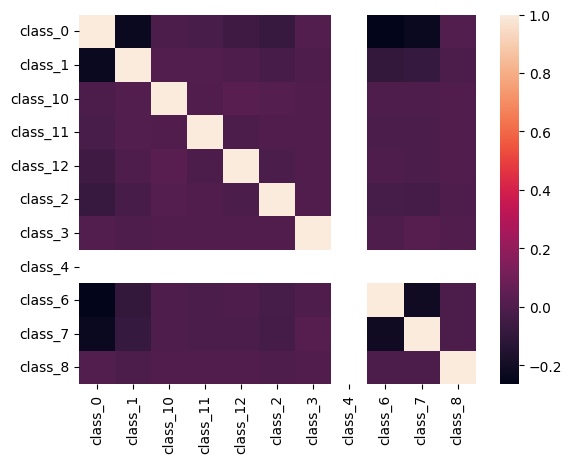

In [24]:
corr_matrix = df.corr()

print(corr_matrix)
sns.heatmap(corr_matrix)

In [ ]:
Jaccard Probability Correlation

c:\Users\Administrator\.virtualenvs\Computer-Vision-Pipeline-6UbSDN57\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 due to no true or predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


          class_0  class_1  class_10  class_11  class_12  class_2  class_3  \
class_0     1.000    0.149     0.006     0.009     0.005    0.014      0.0   
class_1     0.149    1.000     0.007     0.011     0.007    0.015      0.0   
class_10    0.006    0.007     1.000     0.004     0.016    0.010      0.0   
class_11    0.009    0.011     0.004     1.000     0.000    0.007      0.0   
class_12    0.005    0.007     0.016     0.000     1.000    0.000      0.0   
class_2     0.014    0.015     0.010     0.007     0.000    1.000      0.0   
class_3     0.000    0.000     0.000     0.000     0.000    0.000      1.0   
class_4     0.000    0.000     0.000     0.000     0.000    0.000      0.0   
class_6     0.110    0.072     0.006     0.007     0.007    0.012      0.0   
class_7     0.101    0.068     0.006     0.008     0.004    0.009      0.0   
class_8     0.000    0.000     0.000     0.000     0.000    0.000      0.0   

          class_4  class_6  class_7  class_8  
class_0       0.

<Axes: >

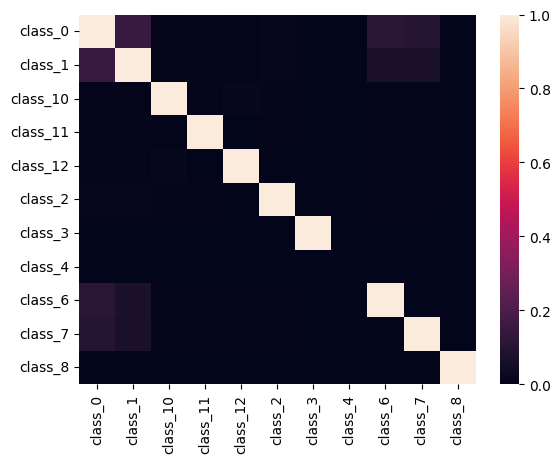

In [25]:
from sklearn.metrics import jaccard_score

classes = df.columns

jaccard = pd.DataFrame(
    index=classes,
    columns=classes,
    dtype=float
)

for c1 in classes:
    for c2 in classes:
        jaccard.loc[c1, c2] = jaccard_score(
            df[c1],
            df[c2]
        )

print(jaccard.round(3))
sns.heatmap(jaccard)

Conditional Probability Correlation

          class_0  class_1  class_10  class_11  class_12  class_2  class_3  \
class_0     1.000    0.534     0.674     0.624     0.452    0.477      1.0   
class_1     0.172    1.000     0.247     0.242     0.212    0.167      0.0   
class_10    0.006    0.007     1.000     0.007     0.029    0.013      0.0   
class_11    0.010    0.011     0.011     1.000     0.000    0.010      0.0   
class_12    0.005    0.007     0.034     0.000     1.000    0.000      0.0   
class_2     0.015    0.016     0.045     0.020     0.000    1.000      0.0   
class_3     0.000    0.000     0.000     0.000     0.000    0.000      1.0   
class_4     0.000    0.000     0.000     0.000     0.000    0.000      0.0   
class_6     0.125    0.123     0.169     0.128     0.173    0.110      0.0   
class_7     0.113    0.110     0.146     0.121     0.096    0.077      1.0   
class_8     0.000    0.000     0.000     0.000     0.000    0.000      0.0   

          class_4  class_6  class_7  class_8  
class_0       Na

<Axes: >

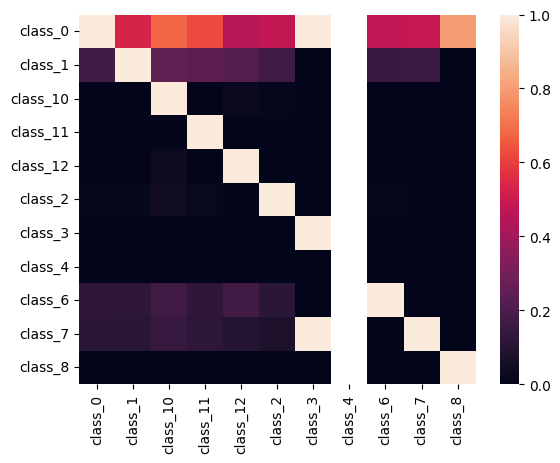

In [26]:
classes = df.columns

cond_prob = pd.DataFrame(
    index=classes,
    columns=classes,
    dtype=float
)

for a in classes:
    for b in classes:

        count_b = df[b].sum()

        if count_b == 0:
            cond_prob.loc[a, b] = np.nan
        else:
            count_ab = ((df[a] == 1) & (df[b] == 1)).sum()
            cond_prob.loc[a, b] = count_ab / count_b

print(cond_prob.round(3))
sns.heatmap(cond_prob)

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_class_distribution(class_counts, class_names=None, title="Class Distribution"):
    
    classes = list(class_counts.keys())
    counts = list(class_counts.values())

    if class_names:
        labels = [class_names[c] for c in classes]
    else:
        labels = classes

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=labels,
        y=counts
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title(title)

    # add values above bars
    for i, count in enumerate(counts):
        plt.text(
            i,
            count,
            str(count),
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

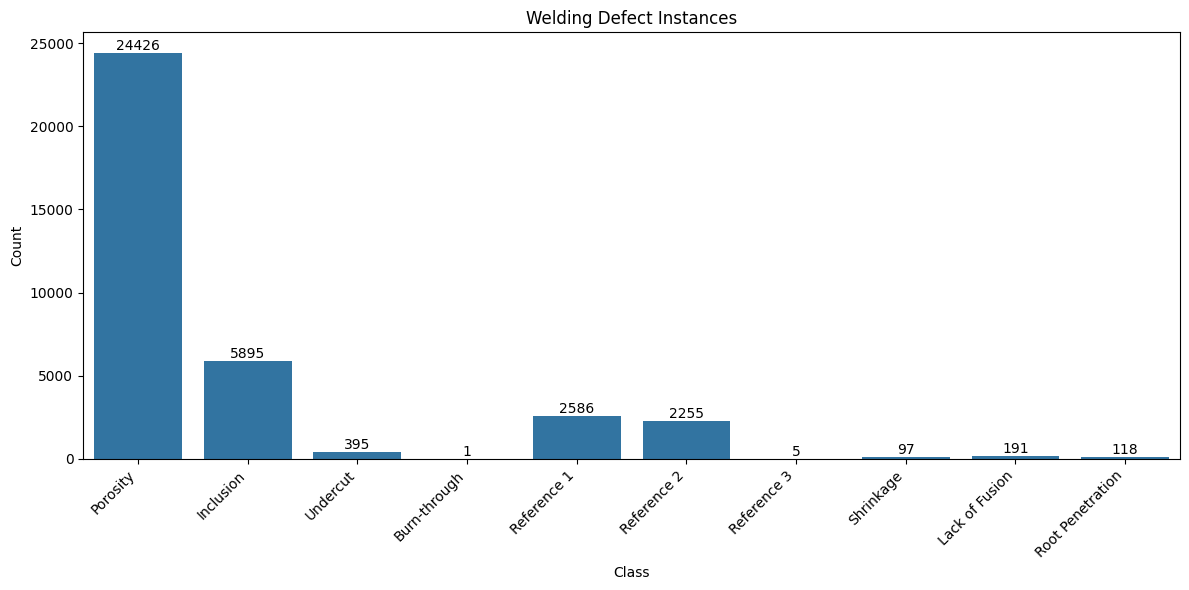

In [28]:
class_names = {
    0: "Porosity",
    1: "Inclusion",
    2: "Undercut",
    3: "Burn-through",
    6: "Reference 1",
    7: "Reference 2",
    8: "Reference 3",
    10: "Shrinkage",
    11: "Lack of Fusion",
    12: "Root Penetration"
}

instances = {
    0: 24426,
    1: 5895,
    2: 395,
    3: 1,
    6: 2586,
    7: 2255,
    8: 5,
    10: 97,
    11: 191,
    12: 118
}

plot_class_distribution(
    instances,
    class_names,
    "Welding Defect Instances"
)

In [29]:
import pandas as pd


def compare_distribution(image_counts, instance_counts, class_names):

    df = pd.DataFrame({
        "Images": image_counts,
        "Instances": instance_counts
    })

    df["Class"] = [
        class_names[i]
        for i in df.index
    ]

    df = df.reset_index(drop=True)

    df.plot(
        x="Class",
        kind="bar",
        figsize=(12,6)
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.ylabel("Count")
    plt.title("Images vs Instances per Class")

    plt.tight_layout()
    plt.show()

In [31]:
class_count = count_images_per_class(r'C:\Users\Administrator\Downloads\Computer-Vision-Pipeline\data\weld_data\train\labels')
print(class_count)

{0: 9776, 1: 3146, 2: 300, 3: 1, 6: 2586, 7: 2255, 8: 5, 10: 89, 11: 149, 12: 104}


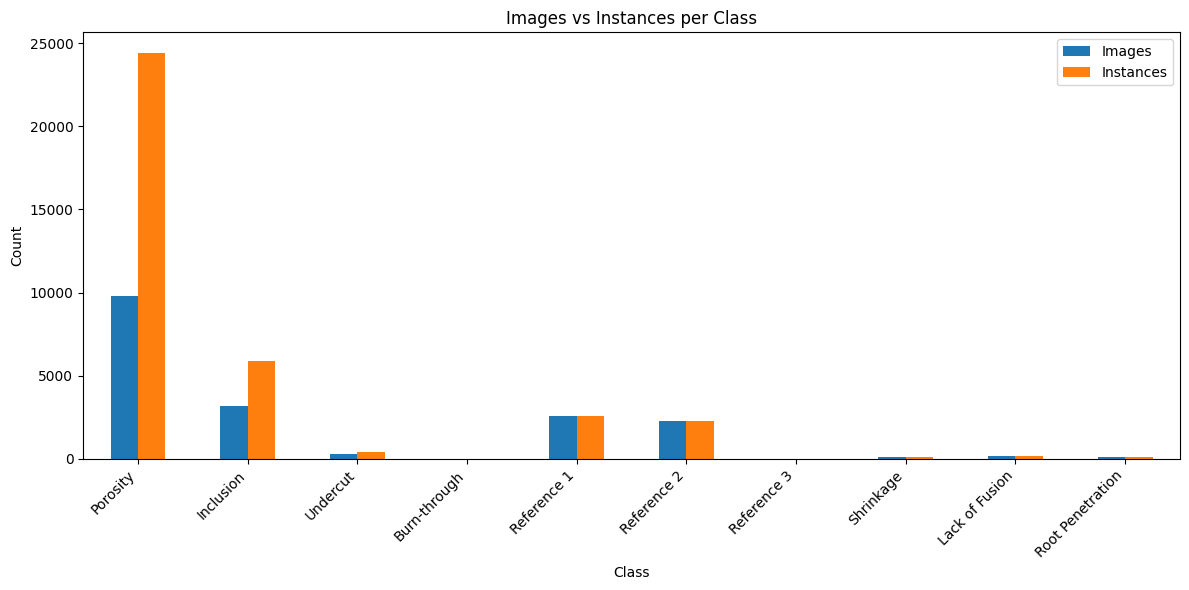

In [32]:
compare_distribution(class_count, instances, class_names)